# DenseNet121 PyTorch Fine-tuning for Rice Disease Classification

Phân loại 4 loại bệnh trên lá lúa sử dụng DenseNet121 với PyTorch

## Bước 1: Import thư viện


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

import os
import cv2
import numpy as np
import time
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils import class_weight
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter


## Bước 2: Cấu hình


In [ ]:
DATA_PATH = "/kaggle/input/data-culilam/content/drive/MyDrive/data/data_preprocessing_cat_vung_la_lua/data_tonghop_tk1"
IMAGE_SIZE = 224
BATCH_SIZE = 64
EPOCHS = 100
PATIENCE = 8

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")
print(f"CUDA available: {torch.cuda.is_available()}")


Device: cuda
CUDA available: True


## Bước 3: Hàm tiền xử lý


In [ ]:
def brighten_image(img):
    return cv2.convertScaleAbs(img, alpha=1.2, beta=30)

def enhance_contrast(img):
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    l = clahe.apply(l)
    lab = cv2.merge((l,a,b))
    return cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

def sharpen_image(img):
    kernel = np.array([[0,-1,0], [-1,5,-1], [0,-1,0]])
    return cv2.filter2D(img, -1, kernel)

def process_image(img_path, target_size=(224, 224)):
    img = cv2.imread(img_path)
    if img is None:
        return None
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = brighten_image(img)
    img = enhance_contrast(img)
    img = sharpen_image(img)
    img = cv2.resize(img, target_size)
    return img

def split_dataset_stratified(data_dir, test_size=0.1, val_size=0.1, random_state=42):
    file_paths = []
    labels = []
    class_names = sorted(os.listdir(data_dir))

    for class_idx, class_name in enumerate(class_names):
        class_dir = os.path.join(data_dir, class_name)
        if os.path.isdir(class_dir):
            for file_name in os.listdir(class_dir):
                if file_name.lower().endswith(('.jpg', '.jpeg', '.png')):
                    file_paths.append(os.path.join(class_dir, file_name))
                    labels.append(class_idx)

    X_temp, X_test, y_temp, y_test = train_test_split(
        file_paths, labels, test_size=test_size,
        random_state=random_state, stratify=labels
    )

    val_size_adjusted = val_size / (1 - test_size)
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=val_size_adjusted,
        random_state=random_state, stratify=y_temp
    )

    return (X_train, X_val, X_test), (y_train, y_val, y_test), class_names


## Bước 4: Load và visualize dữ liệu

Classes: ['Đốm nâu (Brow Spot)', 'Đạo ôn (Leaf Blast)', 'Cháy lá (Leaf Blight)', 'Bình thường (Normal)']
Number of classes: 4
Train samples: 9462
Validation samples: 1183
Test samples: 1183


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


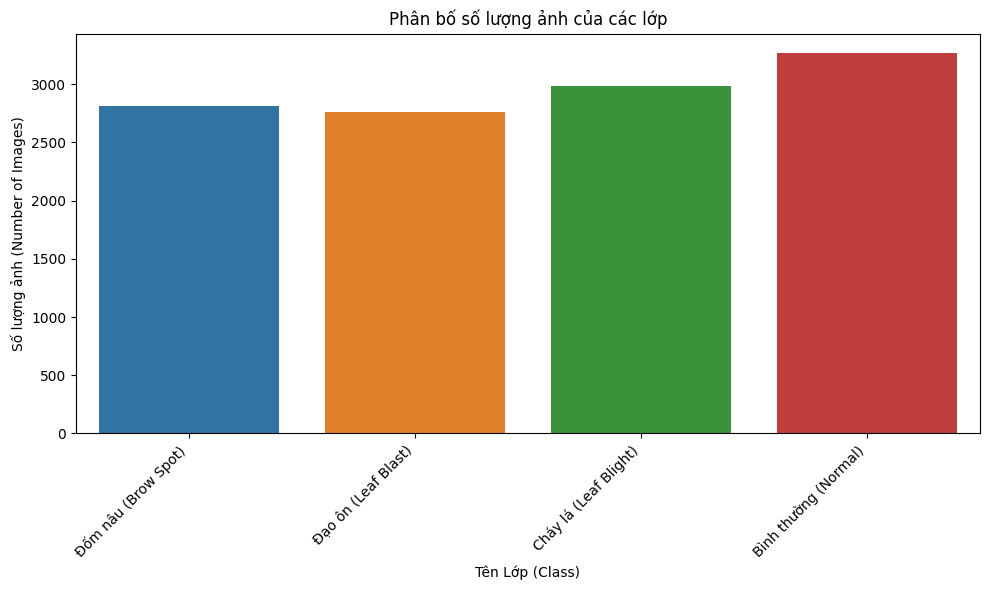

In [ ]:
(X_train, X_val, X_test), (y_train, y_val, y_test), original_class_names = split_dataset_stratified(DATA_PATH)

class_name_mapping = {
    '01': 'Đốm nâu (Brow Spot)',
    '02': 'Đạo ôn (Leaf Blast)',
    '03': 'Cháy lá (Leaf Blight)',
    '04': 'Bình thường (Normal)'
}
class_names = [class_name_mapping.get(name, name) for name in sorted(original_class_names)]
num_classes = len(class_names)

print(f"Classes: {class_names}")
print(f"Number of classes: {num_classes}")
print(f"Train samples: {len(X_train)}")
print(f"Validation samples: {len(X_val)}")
print(f"Test samples: {len(X_test)}")

all_labels_pretty = []
for original_name in sorted(original_class_names):
    class_dir = os.path.join(DATA_PATH, original_name)
    if os.path.isdir(class_dir):
        num_files = len([f for f in os.listdir(class_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        all_labels_pretty.extend([class_name_mapping.get(original_name, original_name)] * num_files)
label_counts = Counter(all_labels_pretty)

plt.figure(figsize=(10, 6))
sns.barplot(x=list(label_counts.keys()), y=list(label_counts.values()))
plt.title('Phân bố số lượng ảnh của các lớp')
plt.xlabel('Tên Lớp (Class)')
plt.ylabel('Số lượng ảnh (Number of Images)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


## Bước 5: Dataset Class


In [ ]:
class RiceDiseaseDataset(Dataset):
    def __init__(self, file_paths, labels, transform=None):
        self.file_paths = file_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        img_path = self.file_paths[idx]
        label = self.labels[idx]

        img = process_image(img_path, target_size=(IMAGE_SIZE, IMAGE_SIZE))
        if img is None:
            img = np.zeros((IMAGE_SIZE, IMAGE_SIZE, 3), dtype=np.uint8)

        img = Image.fromarray(img)

        if self.transform:
            img = self.transform(img)

        return img, label


## Bước 6: Data Transforms và DataLoaders


In [ ]:
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = RiceDiseaseDataset(X_train, y_train, transform=train_transform)
val_dataset = RiceDiseaseDataset(X_val, y_val, transform=val_test_transform)
test_dataset = RiceDiseaseDataset(X_test, y_test, transform=val_test_transform)

class_weights_calculated = class_weight.compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=np.array(y_train)
)
class_weights_dict = dict(enumerate(class_weights_calculated))
print("Class weights:", class_weights_dict)

class_counts = np.bincount(y_train)
class_weights_tensor = 1. / torch.tensor(class_counts, dtype=torch.float)
samples_weights = class_weights_tensor[y_train]

sampler = WeightedRandomSampler(
    weights=samples_weights,
    num_samples=len(samples_weights),
    replacement=True
)

dl_train = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=4)
dl_val = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)
dl_test = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

print(f"Train batches: {len(dl_train)}")
print(f"Validation batches: {len(dl_val)}")
print(f"Test batches: {len(dl_test)}")


Class weights: {0: 1.0518008003557135, 1: 1.0708465368945224, 2: 0.990163248221013, 3: 0.9045889101338432}
Train batches: 148
Validation batches: 19
Test batches: 19


## Bước 7: Model Setup


In [ ]:
model = models.mobilenet_v2(pretrained=True)

model.classifier = nn.Sequential(
    nn.Dropout(0.2),
    nn.Linear(model.last_channel, num_classes)
)

model = model.to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-5)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=True
)

save_path = "/kaggle/working/mobilenetv2_best_model.pth"

print(f"Model: MobileNetV2")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth
100%|██████████| 30.8M/30.8M [00:00<00:00, 188MB/s]


Model: DenseNet121
Total parameters: 7,217,284
Trainable parameters: 7,217,284


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


## Bước 8: Training Function


In [ ]:
def run_epoch(dataloader, train=True):
    model.train(mode=train)
    epoch_loss, correct, total = 0.0, 0, 0

    for images, labels in dataloader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        if train:
            optimizer.zero_grad()

        with torch.set_grad_enabled(train):
            logits = model(images)
            loss = criterion(logits, labels)

            if train:
                loss.backward()
                optimizer.step()

        epoch_loss += loss.item() * images.size(0)
        preds = logits.argmax(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return epoch_loss/total, correct/total


## Bước 9: Training Loop


In [ ]:
train_losses, train_accs = [], []
val_losses, val_accs = [], []

best_val_loss = float('inf')
best_val_acc = 0.0
patience_counter = 0

print("Bắt đầu huấn luyện...")

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    tr_loss, tr_acc = run_epoch(dl_train, train=True)
    val_loss, val_acc = run_epoch(dl_val, train=False)

    scheduler.step(val_loss)

    train_losses.append(tr_loss)
    train_accs.append(tr_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"[{epoch:02d}/{EPOCHS}] "
          f"train_loss={tr_loss:.4f} acc={tr_acc:.4f} | "
          f"val_loss={val_loss:.4f} acc={val_acc:.4f} | "
          f"time={time.time()-t0:.1f}s")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_val_acc = val_acc
        patience_counter = 0
        torch.save({
            "model": model.state_dict(),
            "classes": class_names,
            "optimizer": optimizer.state_dict(),
            "epoch": epoch
        }, save_path)
        print(f"  -> Val loss cải thiện. Lưu model (val_loss={best_val_loss:.4f})")
    else:
        patience_counter += 1
        print(f"  -> Val loss không cải thiện. Patience: {patience_counter}/{PATIENCE}")

    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping ở epoch {epoch}!")
        break

print(f"\nTraining hoàn tất. Best Validation Accuracy: {best_val_acc:.4f}")


Bắt đầu huấn luyện...
[01/100] train_loss=1.2426 acc=0.4696 | val_loss=1.0290 acc=0.6813 | time=270.1s
  -> Val loss cải thiện. Lưu model (val_loss=1.0290)
[02/100] train_loss=0.9003 acc=0.6894 | val_loss=0.6854 acc=0.7794 | time=257.0s
  -> Val loss cải thiện. Lưu model (val_loss=0.6854)
[03/100] train_loss=0.6291 acc=0.7877 | val_loss=0.5019 acc=0.8191 | time=262.9s
  -> Val loss cải thiện. Lưu model (val_loss=0.5019)
[04/100] train_loss=0.4726 acc=0.8407 | val_loss=0.4193 acc=0.8470 | time=258.1s
  -> Val loss cải thiện. Lưu model (val_loss=0.4193)
[05/100] train_loss=0.3749 acc=0.8695 | val_loss=0.3543 acc=0.8757 | time=255.9s
  -> Val loss cải thiện. Lưu model (val_loss=0.3543)
[06/100] train_loss=0.3280 acc=0.8843 | val_loss=0.3041 acc=0.8859 | time=259.2s
  -> Val loss cải thiện. Lưu model (val_loss=0.3041)
[07/100] train_loss=0.2766 acc=0.9044 | val_loss=0.2812 acc=0.8926 | time=253.0s
  -> Val loss cải thiện. Lưu model (val_loss=0.2812)
[08/100] train_loss=0.2512 acc=0.9109 | 

## Bước 10: Evaluation on Test Set


In [ ]:
checkpoint = torch.load(save_path, map_location=DEVICE)
model.load_state_dict(checkpoint['model'])

def calculate_fps(model, dataloader, device, num_warmup=10, num_runs=50):
    model.eval()
    times = []

    # Warm-up (chạy vài lần đầu để ổn định)
    for _ in range(num_warmup):
        try:
            images, _ = next(iter(dataloader))
            images = images.to(device)
            _ = model(images)
        except StopIteration:
            break

    # Đo thời gian
    with torch.no_grad():
        for _ in range(num_runs):
            try:
                images, _ = next(iter(dataloader))
                images = images.to(device)

                start_time = time.time()
                _ = model(images)
                end_time = time.time()

                times.append(end_time - start_time)
            except StopIteration:
                # Đảm bảo dataloader đủ lớn
                break

    if not times:
        return 0.0
    avg_time_per_batch = np.mean(times)
    images_per_batch = dataloader.batch_size
    fps = images_per_batch / avg_time_per_batch
    return fps
model.eval()
test_correct, test_total = 0, 0
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in dl_test:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        logits = model(images)
        preds = logits.argmax(1)

        test_correct += (preds == labels).sum().item()
        test_total += labels.size(0)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_accuracy = test_correct / test_total
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))

fps = calculate_fps(model, dl_test, DEVICE)
print(f"FPS (Frames Per Second) trên tập Test: {fps:.2f} FPS")


Test Accuracy: 0.9298 (92.98%)

Classification Report:
                       precision    recall  f1-score   support

  Đốm nâu (Brow Spot)       0.96      0.92      0.94       281
  Đạo ôn (Leaf Blast)       0.89      0.88      0.89       276
Cháy lá (Leaf Blight)       0.91      0.93      0.92       299
 Bình thường (Normal)       0.96      0.98      0.97       327

             accuracy                           0.93      1183
            macro avg       0.93      0.93      0.93      1183
         weighted avg       0.93      0.93      0.93      1183



## Bước 11: Visualization


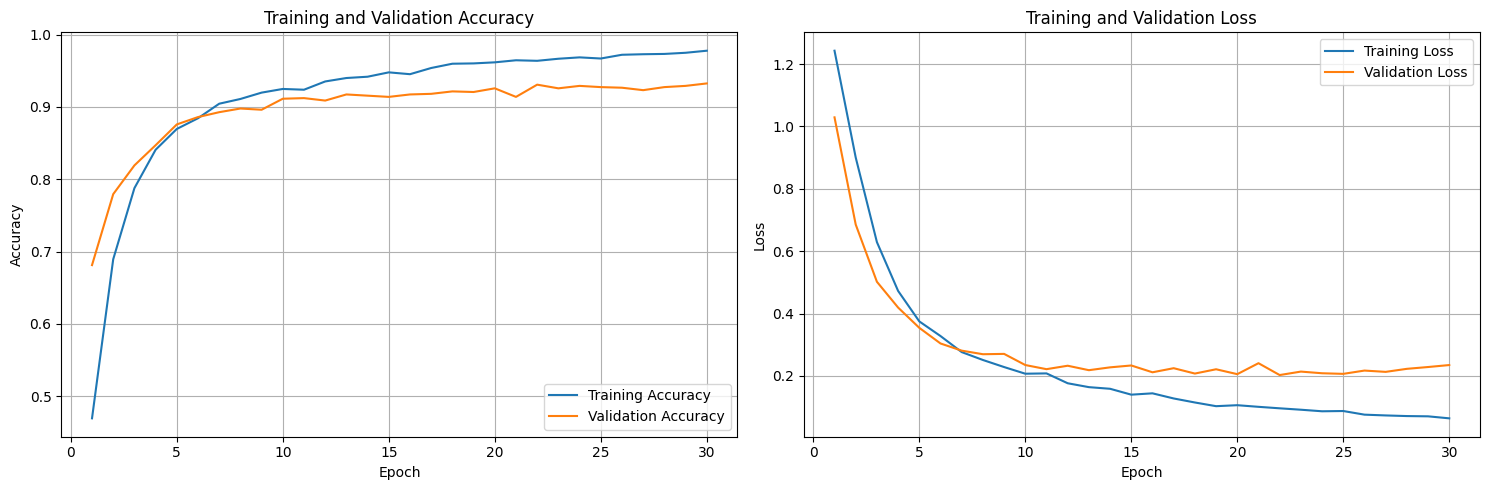

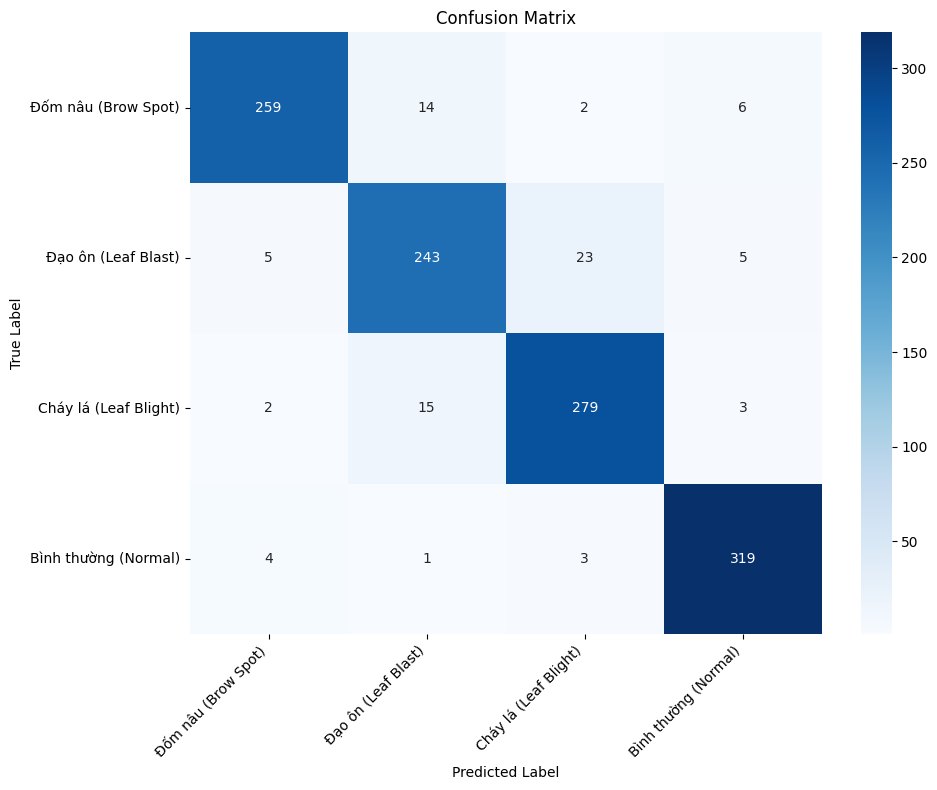

In [ ]:
epochs_range = range(1, len(train_accs) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(epochs_range, train_accs, label='Training Accuracy')
ax1.plot(epochs_range, val_accs, label='Validation Accuracy')
ax1.legend(loc='lower right')
ax1.set_title('Training and Validation Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.grid(True)

ax2.plot(epochs_range, train_losses, label='Training Loss')
ax2.plot(epochs_range, val_losses, label='Validation Loss')
ax2.legend(loc='upper right')
ax2.set_title('Training and Validation Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.grid(True)

plt.tight_layout()
plt.show()

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()
